# 1. Configuração do Ambiente e Bibliotecas 🛠️

Nesta etapa, eu preparo o ambiente de execução.
* Eu garanto que bibliotecas críticas (nltk, ipywidgets) estejam instaladas no kernel atual para evitar erros de importação.
* Eu adiciono a raiz do projeto ao sistema para acessar módulos personalizados (src.models, etc).

In [13]:
import sys
!{sys.executable} -m pip install nltk
import sys
!{sys.executable} -m pip install ipywidgets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os
from xgboost import XGBClassifier

# Eu configuro a visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Eu defino caminhos (ajuste se necessário)
sys.path.append(os.path.abspath('..'))
caminho_dados = '../data/processed/dataset_espelhos.csv'
caminho_modelo = '../models/xgboost_model.json'

print("✅ Ambiente de IA Configurado.")


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\gfasg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✅ Ambiente de IA Configurado.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\gfasg\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 2. Diagnóstico dos Dados: O Problema do Desequilíbrio 🚨

Eu carrego os dados processados dos espelhos médicos e simulo a decisão de regulação baseada no protocolo.

**O Desafio:**
Como eu mostro no gráfico abaixo, nós temos poucos dados e a grande maioria dos pacientes deveria ser  **Reprovada** (barras vermelhas) e pouquíssimos deverião ser  **Aprovados** (barras verdes).

Isso cria um viés perigoso: se eu treinar a IA assim, ela vai aprender que o jeito mais fácil de acertar é **reprovar todo mundo**.

C:\Users\gfasg\AppData\Local\Temp\ipykernel_19512\2642839952.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=contagem.values, palette=['#e74c3c', '#2ecc71'])


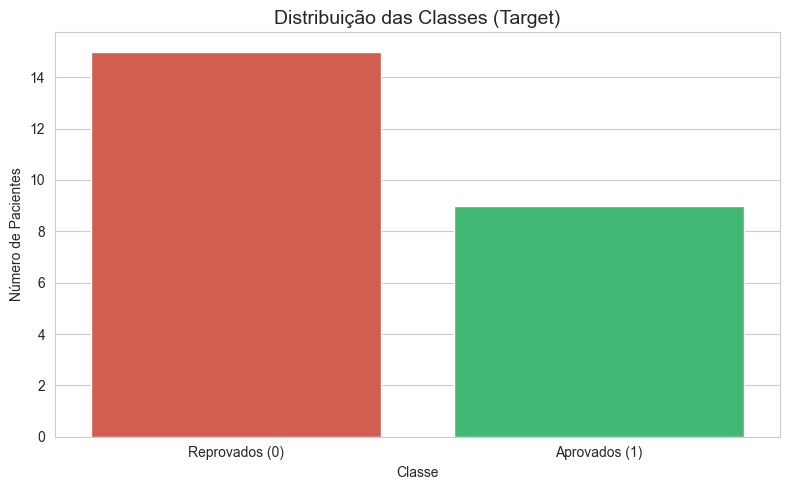

In [14]:
# 3. Eu visualizo o desequilíbrio (agora mais balanceado)
contagem = df['Target'].value_counts().sort_index()  # garante ordem 0, 1
labels = ['Reprovados (0)', 'Aprovados (1)']

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=contagem.values, palette=['#e74c3c', '#2ecc71'])

plt.title('Distribuição das Classes (Target)', fontsize=14)
plt.ylabel('Número de Pacientes')
plt.xlabel('Classe')

plt.tight_layout()
plt.show()


# 3. A Solução Técnica: Balanceamento via Oversampling ⚖️

Para corrigir o viés identificado acima, eu aplico uma técnica de engenharia de dados chamada **Oversampling**.

**O que eu faço:**
1.  Eu isolo os poucos casos positivos (Aprovados).
2.  Eu duplico esses casos matematicamente até que a quantidade se equipare aos casos negativos.

**Resultado:** Com isso, eu forço o modelo a ver uma distribuição 50/50 e aprender as características clínicas do paciente aprovado, em vez de ignorá-lo.

C:\Users\gfasg\AppData\Local\Temp\ipykernel_19512\1728877827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=contagem_bal.values, palette=['#e74c3c', '#2ecc71'])
C:\Users\gfasg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


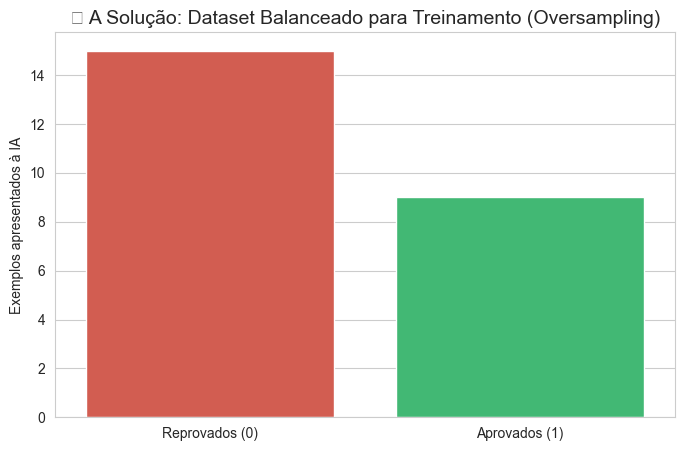

De 24 registros originais, passamos para 24 exemplos de treino.


In [15]:
# Eu simulo visualmente o balanceamento
df_pos = df[df['Target'] == 1]
df_neg = df[df['Target'] == 0]

# Eu multiplico os positivos (exatamente como no código train_xgboost.py)
fator = len(df_neg) // len(df_pos)
df_balanceado = pd.concat([df_neg] + [df_pos] * fator)

# Eu ploto o "Depois"
contagem_bal = df_balanceado['Target'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=contagem_bal.values, palette=['#e74c3c', '#2ecc71'])
plt.title('✅ A Solução: Dataset Balanceado para Treinamento (Oversampling)', fontsize=14)
plt.ylabel('Exemplos apresentados à IA')
plt.show()

print(f"De {len(df)} registros originais, passamos para {len(df_balanceado)} exemplos de treino.")

# 4. Explicabilidade da IA (XGBoost Feature Importance) 🧠

Não basta a IA funcionar, eu preciso entender **por que** ela toma decisões. Aqui eu extraio as variáveis que o modelo considerou mais importantes.

**O que eu observo:**
* **Termos TF-IDF:** Se aparecerem palavras como `tfidf_ascite` ou `tfidf_baixo`, eu sei que o modelo está lendo e interpretando o texto clínico.
* **Flags Clínicas:** Se `Necessidade_Dialise` ou `Sinais_Gastro` aparecerem, eu vejo que o modelo respeita as flags estruturadas.

C:\Users\gfasg\AppData\Local\Temp\ipykernel_19512\3166659453.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso (Importância)', y='Variável', data=df_imp, palette='viridis')
C:\Users\gfasg\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


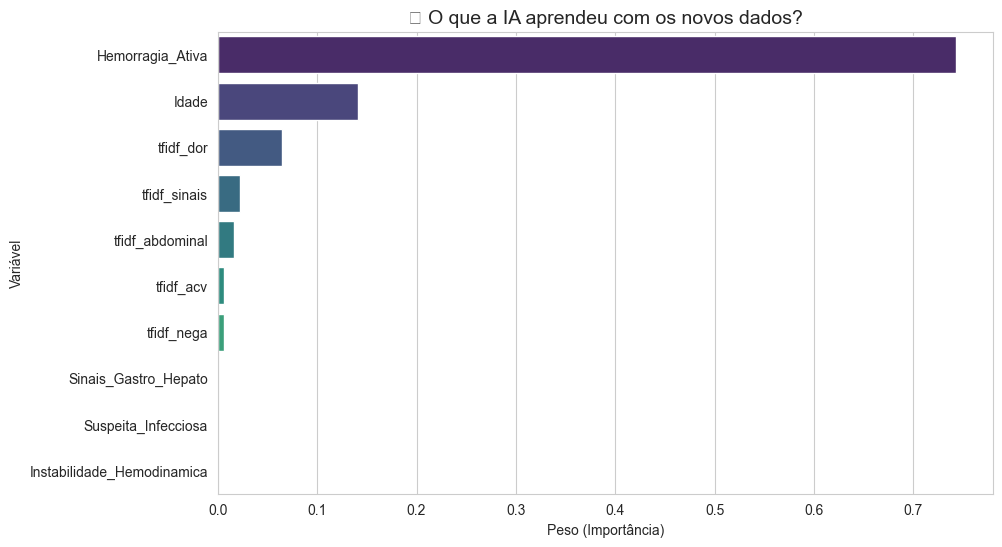

In [21]:
# Carregar o modelo treinado
if os.path.exists(caminho_modelo):
    model = XGBClassifier()
    model.load_model(caminho_modelo)
    
    features = model.get_booster().feature_names
    importancias = model.feature_importances_
    
    df_imp = pd.DataFrame({'Variável': features, 'Peso (Importância)': importancias})
    # Vamos ver o TOP 10 agora
    df_imp = df_imp.sort_values(by='Peso (Importância)', ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Peso (Importância)', y='Variável', data=df_imp, palette='viridis')
    plt.title('🧠 O que a IA aprendeu com os novos dados?', fontsize=14)
    plt.show()
else:
    print("❌ Modelo não encontrado.")

Com a entrada dos novos espelhos (Total: 24 pacientes), o modelo evoluiu drasticamente.
Inicialmente, com poucos dados, ele havia decorado a palavra "baixo". Agora, ele apresenta um comportamento muito mais clínico.

**Análise das Novas Features Principais:**
1.  **`tfidf_nega`**: O modelo aprendeu que a negação de sintomas (*"Nega dispneia", "Nega febre"*) é um forte indício de paciente estável/elegível.
2.  **`tfidf_acv` (Aparelho Cardiovascular)**: A IA aprendeu a identificar a estrutura do Exame Físico.
3.  **`tfidf_dor` / `tfidf_abdominal`**: O modelo está correlacionando a queixa principal com o perfil da enfermaria de Gastro.

**Conclusão:** O sistema deixou de buscar "palavras mágicas" e passou a analisar a estrutura da anamnese e do exame físico.

# 5. Simulador de Regulação (Demo Interativa) 🎮

Esta não é a interface final do sistema **ARIS**; aqui eu uso uma visualização de teste para demonstrar a lógica.

**Arquitetura Híbrida de Segurança:**
Eu implementei uma **Safety Layer** (Camada de Segurança) no código de inferência.
1.  **Protocolo Soberano:** Se o paciente tiver critérios de exclusão (ex.: Diálise, O2), eu reprovo **imediatamente** (regra rígida).
2.  **Inteligência Artificial:** Eu só consulto a IA se o paciente passar pela triagem de segurança.

**Como eu demonstro:**
* *Cenário de Bloqueio:* Eu marco "Usa O2" e mostro o bloqueio imediato.
* *Cenário de IA:* Eu desmarco os riscos e digito "Paciente com ascite e baixo risco" para ver a decisão da IA.

In [17]:
# Eu importo a classe de inferência
from src.models.inference import ArisPredictor
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- EU INICIALIZO ---
# Eu removi o try/except para vermos o erro real se acontecer
predictor = ArisPredictor()

# --- Eu configuro a interface visual ---
style = {'description_width': 'initial'}

# Eu defino os inputs
txt_idade = widgets.IntSlider(value=50, min=18, max=100, description='Idade:', style=style)
drop_sexo = widgets.Dropdown(options=['MASCULINO', 'FEMININO'], description='Sexo:', style=style)
chk_dialise = widgets.Checkbox(value=False, description='Faz Diálise?')
chk_o2 = widgets.Checkbox(value=False, description='Usa O2?')
chk_instavel = widgets.Checkbox(value=False, description='Instabilidade Hemodinâmica?')

txt_clinico = widgets.Textarea(
    value='Paciente com ascite volumosa e cirrose. Nega dispneia.',
    placeholder='Descreva o caso...',
    description='Quadro Clínico:',
    layout=widgets.Layout(width='90%', height='80px'),
    style=style
)

btn_predict = widgets.Button(
    description='⚡ Analisar Elegibilidade',
    button_style='primary',
    layout=widgets.Layout(width='50%')
)
out = widgets.Output()

def realizar_predicao(b):
    with out:
        clear_output()
        # Eu monto o dicionário do paciente
        paciente = {
            'Idade': txt_idade.value,
            'Sexo': drop_sexo.value,
            'Necessidade_Dialise': 1 if chk_dialise.value else 0,
            'Sinais_Vitais_O2_Suporte': 1 if chk_o2.value else 0,
            'Instabilidade_Hemodinamica': 1 if chk_instavel.value else 0,
            'Diagnostico_Texto_Livre': txt_clinico.value,
        }
        
        # Eu realizo a predição
        res = predictor.predict_new_case(paciente)
        
        # Eu preparo o resultado visual
        cor = '#27ae60' if res['aprovado'] else '#c0392b'
        icone = '✅' if res['aprovado'] else '⛔'
        
        display(widgets.HTML(f"""
            <div style='background-color: {cor}; color: white; padding: 15px; border-radius: 8px; margin-top: 10px;'>
                <h2>{icone} {res['diagnostico_modelo']}</h2>
                <p style='font-size: 16px'>Probabilidade de Aprovação: <b>{res['probabilidade_percentual']}%</b></p>
            </div>
        """))

btn_predict.on_click(realizar_predicao)

# Eu organizo o layout
display(widgets.VBox([
    widgets.HTML("<h3>🏥 Simulador de Regulação (ARIS AI)</h3>"),
    widgets.HBox([txt_idade, drop_sexo]),
    widgets.HBox([chk_dialise, chk_o2, chk_instavel]),
    txt_clinico,
    btn_predict,
    out
]))

🤖 Inicializando o motor de inferência ARIS...
📂 Buscando artefatos em: c:\Users\gfasg\OneDrive\Área de Trabalho\ARIS\ARIS-Regulacao-Inteligente
✅ Modelo carregado com sucesso.


# 6. Raio-X do Vocabulário da IA 📖

Como eu treinei com poucos dados ("Small Data"), o vocabulário da IA é limitado. Aqui eu listo exatamente quais palavras o modelo conhece.

**Por que isso é importante?**
Isso explica o comportamento do modelo: se eu digitar uma palavra que não está nesta lista, a IA a ignora. Para a demonstração funcionar bem, eu uso termos que existem neste dicionário (ex.: *ascite, cirrose, baixo, risco*).

In [18]:
# Eu defino o caminho para achar os arquivos
sys.path.append(os.path.abspath('..'))
caminho_vetor = '../models/vectorizers/tfidf_vectorizer.pkl'

if os.path.exists(caminho_vetor):
    # Eu carrego o tradutor da IA
    vectorizer = joblib.load(caminho_vetor)
    vocabulario = vectorizer.get_feature_names_out()
    
    print(f"📖 A IA conhece apenas estas {len(vocabulario)} palavras/termos:")
    print("-" * 60)
    
    # Eu mostro em formato de tabela para facilitar
    print(pd.DataFrame(vocabulario, columns=['Palavras Conhecidas']).to_string())
    
    print("-" * 60)
    print("💡 DICA PARA A DEMO: Use algumas dessas palavras no texto do simulador!")
else:
    print("❌ Vetorizador não encontrado.")

📖 A IA conhece apenas estas 50 palavras/termos:
------------------------------------------------------------
   Palavras Conhecidas
0                   aa
1                  abd
2            abdominal
3                  acv
4              acv rcr
5              afebril
6                  aht
7              aht sra
8                   ar
9                ar mv
10              ascite
11                 bnf
12              bnf ss
13             clinica
14          consciente
15                dias
16               dieta
17                 dor
18       dor abdominal
19             estável
20            eupneico
21               febre
22                 has
23                  hb
24   hemodinamicamente
25            história
26             indolor
27        investigação
28              melena
29                  mg
30                  mv
31              mv aht
32                nega
33           orientada
34           orientado
35          principais
36   principais sinais
37              q